# ==================================================
# TASK 1: DATA LOADING & EXPLORATION
# ==================================================

In [2]:
# ----------------------------------------------------------
# Import Required Libraries
# ----------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    f1_score,
    precision_score,
    recall_score
)

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

In [3]:
# ----------------------------------------------------------
# Load Dataset
# ----------------------------------------------------------

raw = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [4]:
# ----------------------------------------------------------
# Display First 10 Rows
# ----------------------------------------------------------

print("First 10 Rows")

display(raw.head(10))

First 10 Rows


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [5]:
# ----------------------------------------------------------
# Check Dataset Shape
# ----------------------------------------------------------

print("Dataset Shape")

print(raw.shape)

print("\nRows :", raw.shape[0])

print("Columns :", raw.shape[1])

Dataset Shape
(1470, 35)

Rows : 1470
Columns : 35


In [6]:
# ----------------------------------------------------------
# Target Variable and Feature Columns
# ----------------------------------------------------------

target = "Attrition"

features = [col for col in raw.columns if col != target]

print("Target Variable :")

print(target)

print("\nFeature Columns :")

print(features)

Target Variable :
Attrition

Feature Columns :
['Age', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [7]:
# ----------------------------------------------------------
# Employees Left vs Stayed
# ----------------------------------------------------------

stayed = (raw["Attrition"] == "No").sum()

left = (raw["Attrition"] == "Yes").sum()

print("Employees Stayed :", stayed)

print("Employees Left :", left)

# ----------------------------------------------------------
# Attrition Rate
# ----------------------------------------------------------

rate = left / len(raw) * 100

print(f"Overall Attrition Rate : {rate:.2f}%")

Employees Stayed : 1233
Employees Left : 237
Overall Attrition Rate : 16.12%


In [8]:
# ----------------------------------------------------------
# Numeric and Categorical Columns
# ----------------------------------------------------------

numeric_cols = raw.select_dtypes(include=np.number).columns

categorical_cols = raw.select_dtypes(include="object").columns

print("Number of Numeric Columns :", len(numeric_cols))

print("Number of Categorical Columns :", len(categorical_cols))

Number of Numeric Columns : 26
Number of Categorical Columns : 9


In [9]:
# ----------------------------------------------------------
# Check Duplicate Rows
# ----------------------------------------------------------

print("Duplicate Rows :", raw.duplicated().sum())

Duplicate Rows : 0


In [10]:
# ----------------------------------------------------------
# Display Data Types
# ----------------------------------------------------------

print(raw.dtypes)

Age                         int64
Attrition                     str
BusinessTravel                str
DailyRate                   int64
Department                    str
DistanceFromHome            int64
Education                   int64
EducationField                str
EmployeeCount               int64
EmployeeNumber              int64
EnvironmentSatisfaction     int64
Gender                        str
HourlyRate                  int64
JobInvolvement              int64
JobLevel                    int64
JobRole                       str
JobSatisfaction             int64
MaritalStatus                 str
MonthlyIncome               int64
MonthlyRate                 int64
NumCompaniesWorked          int64
Over18                        str
OverTime                      str
PercentSalaryHike           int64
PerformanceRating           int64
RelationshipSatisfaction    int64
StandardHours               int64
StockOptionLevel            int64
TotalWorkingYears           int64
TrainingTimesL

## Observation

- The dataset contains **1,470 employee records** and **35 columns**.
- The target variable is **Attrition**, indicating whether an employee left the company.
- There are **1,233 employees who stayed** and **237 employees who left**, resulting in an **attrition rate of approximately 16.1%**.
- The dataset is **imbalanced**, as significantly fewer employees left than stayed. Therefore, techniques such as `class_weight='balanced'` and evaluation metrics like Precision, Recall, F1-score, and ROC-AUC will provide a better assessment than accuracy alone.
- No missing values or duplicate records were found, indicating that the dataset is clean and ready for preprocessing.

# ==========================================================
# Task 2 - Data Cleaning & Preprocessing
# ==========================================================

In [11]:
# ----------------------------------------------------------
# Check Missing Values
# -----------------------------------------------------------

print("Missing Values in Each Column")

print(raw.isnull().sum())

Missing Values in Each Column
Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCur

In [12]:
# ----------------------------------------------------------
# Remove Irrelevant Columns
# ----------------------------------------------------------

df = raw.drop(
    columns=[
        "EmployeeNumber",
        "EmployeeCount",
        "Over18",
        "StandardHours"
    ]
)

print("Remaining Columns :", df.shape[1])

Remaining Columns : 31


In [13]:
# ----------------------------------------------------------
# Convert Target Variable
# ----------------------------------------------------------

df["Attrition"] = df["Attrition"].map({
    "Yes":1,
    "No":0
})

print(df["Attrition"].value_counts())

Attrition
0    1233
1     237
Name: count, dtype: int64


In [14]:
# ----------------------------------------------------------
# Identify Categorical Columns
# ----------------------------------------------------------

categorical_columns = df.select_dtypes(include="object").columns

print("Categorical Columns")

print(categorical_columns)

Categorical Columns
Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus', 'OverTime'],
      dtype='str')


In [15]:
# ----------------------------------------------------------
# Apply One-Hot Encoding
# ----------------------------------------------------------

df = pd.get_dummies(
    df,
    columns=categorical_columns,
    drop_first=True
)

print("Dataset Shape After Encoding")

print(df.shape)

Dataset Shape After Encoding
(1470, 45)


In [16]:
# ----------------------------------------------------------
# Separate Features and Target
# ----------------------------------------------------------

X = df.drop("Attrition", axis=1)

y = df["Attrition"]

print("Feature Matrix Shape :", X.shape)

print("Target Shape :", y.shape)

Feature Matrix Shape : (1470, 44)
Target Shape : (1470,)


In [17]:
# ----------------------------------------------------------
# Standardize Numerical Features
# ----------------------------------------------------------

numeric_columns = X.select_dtypes(include=np.number).columns

scaler = StandardScaler()

X[numeric_columns] = scaler.fit_transform(
    X[numeric_columns]
)

print("Feature Scaling Completed")

Feature Scaling Completed


In [18]:
# ----------------------------------------------------------
# Final Dataset Information
# ----------------------------------------------------------

print("Final Dataset Shape")

print(df.shape)

display(df.head())

Final Dataset Shape
(1470, 45)


,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1,1102,1,2,2,94,3,2,4,...,False,False,False,False,False,True,False,False,True,True
1,49,0,279,8,1,3,61,2,2,2,...,False,False,False,False,True,False,False,True,False,False
2,37,1,1373,2,2,4,92,2,1,3,...,True,False,False,False,False,False,False,False,True,True
3,33,0,1392,3,4,4,56,3,1,3,...,False,False,False,False,True,False,False,True,False,True
4,27,0,591,2,1,1,40,3,1,2,...,True,False,False,False,False,False,False,True,False,False


## Observation

- The dataset contained no missing values.
- Four irrelevant columns (EmployeeNumber, EmployeeCount, Over18, and StandardHours) were removed because they do not contribute to predicting employee attrition.
- The target variable **Attrition** was converted into binary format (Yes = 1, No = 0).
- All categorical features were converted into numerical values using One-Hot Encoding.
- Numerical features were standardized using **StandardScaler**, ensuring that all features are on a comparable scale for machine learning models.
- The dataset is now fully preprocessed and ready for exploratory data analysis and model training.

# ==========================================================
# Task 3 - Exploratory Data Analysis (EDA)
# ==========================================================

               Department  Attrition Rate (%)
0         Human Resources           19.047619
1  Research & Development           13.839750
2                   Sales           20.627803


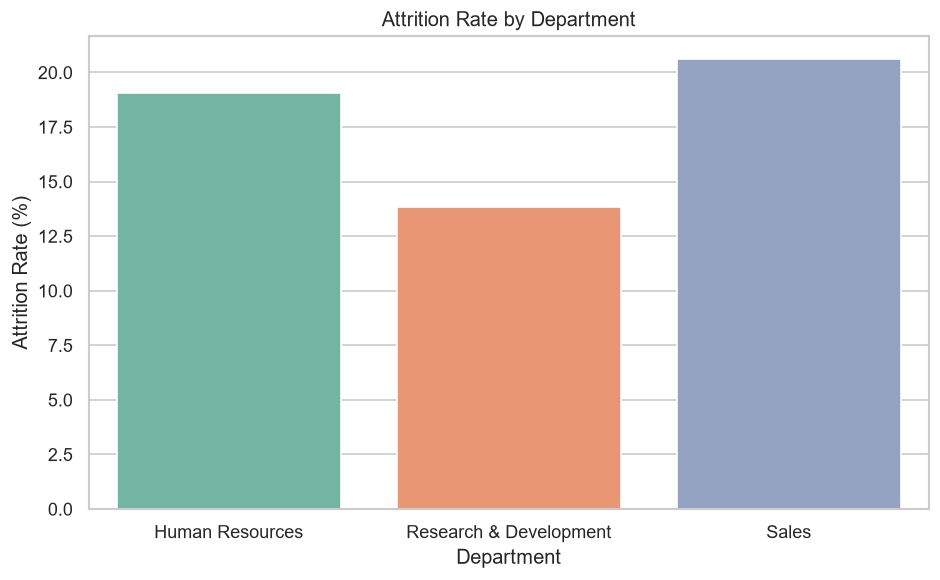

In [19]:
# ----------------------------------------------------------
# EDA 1: Attrition Rate by Department
# ----------------------------------------------------------

# Calculate attrition rate for each department
department_attrition = (
    raw.groupby("Department")["Attrition"]
       .apply(lambda x: (x == "Yes").mean() * 100)
       .reset_index(name="Attrition Rate (%)")
)

print(department_attrition)

# Plot the attrition rate
plt.figure(figsize=(8,5))

sns.barplot(
    data=department_attrition,
    x="Department",
    y="Attrition Rate (%)",
    palette="Set2"
)

plt.title("Attrition Rate by Department")
plt.xlabel("Department")
plt.ylabel("Attrition Rate (%)")

plt.tight_layout()
plt.show()

                     JobRole  Attrition Rate (%)
0  Healthcare Representative            6.870229
1            Human Resources           23.076923
2      Laboratory Technician           23.938224
3                    Manager            4.901961
4     Manufacturing Director            6.896552
5          Research Director            2.500000
6         Research Scientist           16.095890
7            Sales Executive           17.484663
8       Sales Representative           39.759036


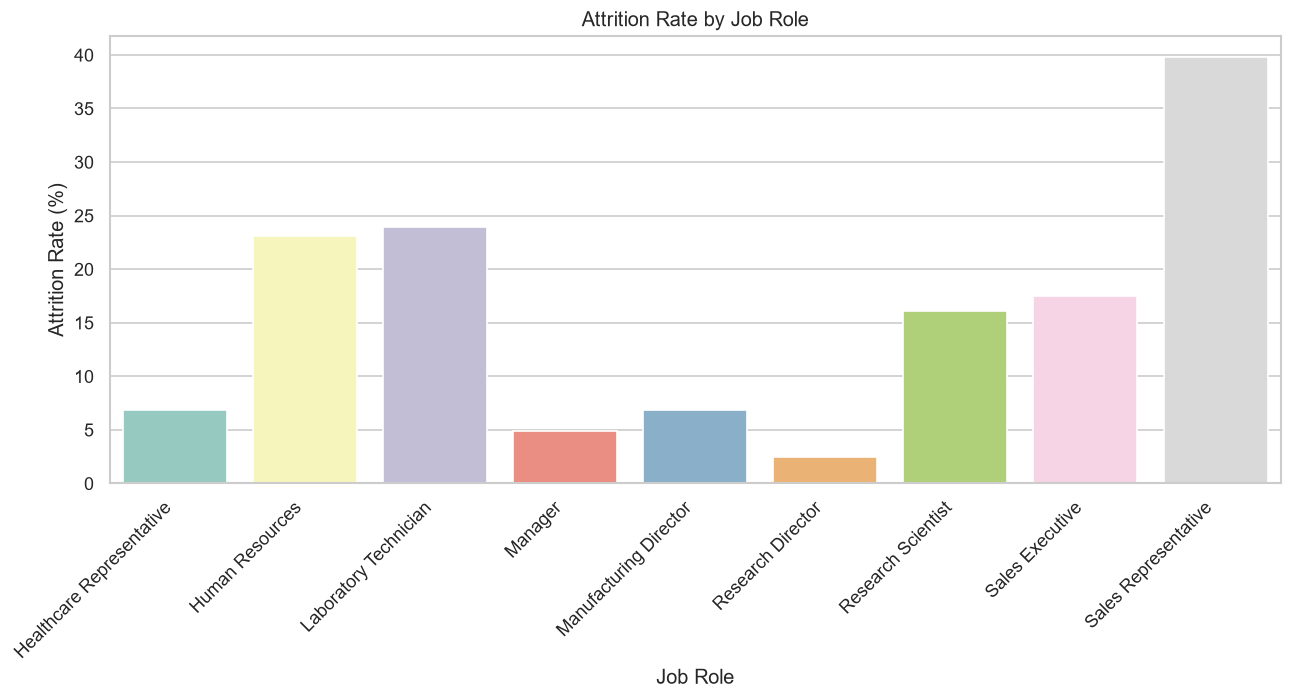

In [20]:
# ----------------------------------------------------------
# EDA 2: Attrition Rate by Job Role
# ----------------------------------------------------------

# Calculate attrition rate for each job role
jobrole_attrition = (
    raw.groupby("JobRole")["Attrition"]
       .apply(lambda x: (x == "Yes").mean() * 100)
       .reset_index(name="Attrition Rate (%)")
)

print(jobrole_attrition)

# Plot the attrition rate
plt.figure(figsize=(11,6))

sns.barplot(
    data=jobrole_attrition,
    x="JobRole",
    y="Attrition Rate (%)",
    palette="Set3"
)

plt.title("Attrition Rate by Job Role")
plt.xlabel("Job Role")
plt.ylabel("Attrition Rate (%)")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

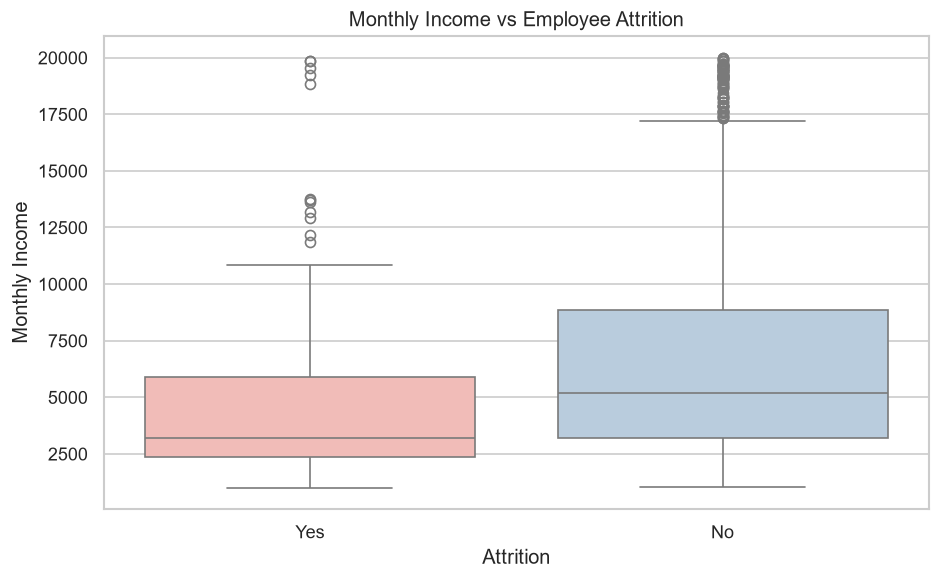

In [21]:

# ----------------------------------------------------------
# EDA 3: Attrition vs Monthly Income
# ----------------------------------------------------------

plt.figure(figsize=(8,5))

sns.boxplot(
    data=raw,
    x="Attrition",
    y="MonthlyIncome",
    palette="Pastel1"
)

plt.title("Monthly Income vs Employee Attrition")
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")

plt.tight_layout()


plt.show()

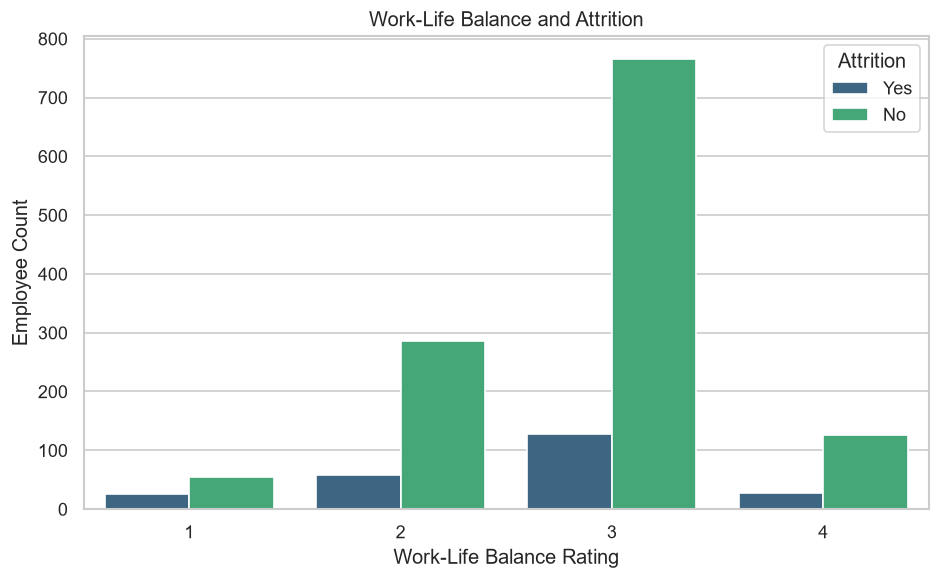

In [22]:
# ----------------------------------------------------------
# EDA 4: Attrition  vs Work-Life Balance rating
# ----------------------------------------------------------

plt.figure(figsize=(8,5))

sns.countplot(
    data=raw,
    x="WorkLifeBalance",
    hue="Attrition",
    palette="viridis"
)

plt.title("Work-Life Balance and Attrition")
plt.xlabel("Work-Life Balance Rating")
plt.ylabel("Employee Count")

plt.tight_layout()


plt.show()

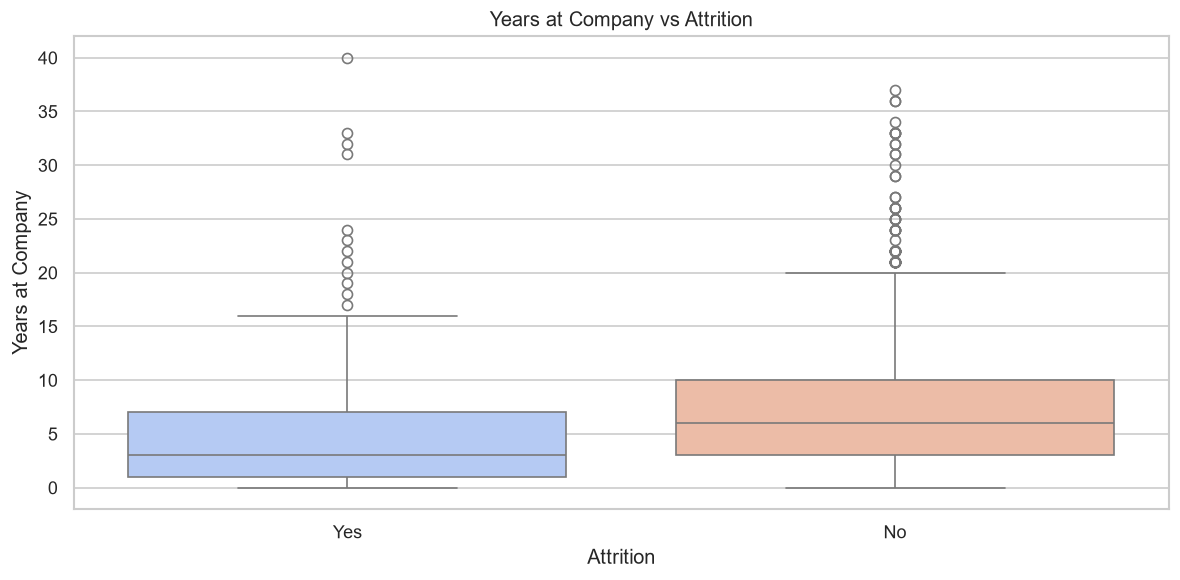

In [23]:
# ----------------------------------------------------------
# EDA 5: Attrition vs Years at Company 
# ----------------------------------------------------------

plt.figure(figsize=(10,5))

sns.boxplot(
    data=raw,
    x="Attrition",
    y="YearsAtCompany",
    palette="coolwarm"
)

plt.title("Years at Company vs Attrition")
plt.xlabel("Attrition")
plt.ylabel("Years at Company")

plt.tight_layout()


plt.show()

## Business Insights

1. The Sales department has the highest attrition rate among all departments, indicating that employees in this department are more likely to leave. HR should prioritize retention initiatives for this group.

2. Sales Representatives and Laboratory Technicians have the highest attrition rates among all job roles, suggesting these positions require focused retention strategies.

3. Employees with lower monthly incomes tend to have higher attrition rates, indicating that compensation may influence employee retention.

4. Employees with lower work-life balance ratings exhibit higher attrition rates, highlighting the importance of promoting a healthier work-life balance.

5. The attrition rate is highest during the early years of employment, suggesting that stronger onboarding, mentoring, and career development programs could improve employee retention.

# ==========================================================
# Task 4 - Model Building & Comparison
# ==========================================================

In [24]:
# ----------------------------------------------------------
# Split Dataset into Training and Testing Sets
# ----------------------------------------------------------

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples :", X_train.shape[0])
print("Testing Samples  :", X_test.shape[0])

Training Samples : 1176
Testing Samples  : 294


In [25]:
# ----------------------------------------------------------
# Train Logistic Regression Model
# ----------------------------------------------------------

from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=1000
)

log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)

log_prob = log_model.predict_proba(X_test)[:,1]

print("Logistic Regression Model Trained Successfully")

Logistic Regression Model Trained Successfully


In [26]:
# ----------------------------------------------------------
# Train Random Forest Classifier
# ----------------------------------------------------------

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_prob = rf_model.predict_proba(X_test)[:,1]

print("Random Forest Model Trained Successfully")

Random Forest Model Trained Successfully


In [27]:
# ----------------------------------------------------------
# Train Gradient Boosting Classifier
# ----------------------------------------------------------

from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    random_state=42
)

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)

gb_prob = gb_model.predict_proba(X_test)[:,1]

print("Gradient Boosting Model Trained Successfully")

Gradient Boosting Model Trained Successfully


In [28]:
# ----------------------------------------------------------
# Compare All Models
# ----------------------------------------------------------

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

comparison = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Precision":[
        precision_score(y_test, log_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, gb_pred)
    ],
    "Recall":[
        recall_score(y_test, log_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, gb_pred)
    ],
    "F1 Score":[
        f1_score(y_test, log_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, gb_pred)
    ],
    "ROC-AUC":[
        roc_auc_score(y_test, log_prob),
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, gb_prob)
    ]
})

comparison = comparison.round(3)

comparison

,Model,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.356,0.660,0.463,0.804
1,Random Forest,0.438,0.298,0.354,0.779
2,Gradient Boosting,0.588,0.213,0.312,0.794


In [29]:
# ----------------------------------------------------------
# Identify the Best Performing Model
# ----------------------------------------------------------

best_model = comparison.sort_values(
    by="ROC-AUC",
    ascending=False
)

print("Best Model Based on ROC-AUC")

display(best_model)

Best Model Based on ROC-AUC


,Model,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.356,0.660,0.463,0.804
2,Gradient Boosting,0.588,0.213,0.312,0.794
1,Random Forest,0.438,0.298,0.354,0.779


## Observation

Three classification models were trained using the preprocessed dataset:

- Logistic Regression
- Random Forest Classifier
- Gradient Boosting Classifier

To address the class imbalance, **class_weight='balanced'** was used for Logistic Regression and Random Forest. Model performance was compared using Precision, Recall, F1-Score, and ROC-AUC. The best-performing model will be selected based on its overall ability to correctly identify employees who are likely to leave while minimizing false predictions.

# ==========================================================
# Task 5 - Model Evaluation
# ==========================================================

In [30]:
# ----------------------------------------------------------
# Classification Report - Logistic Regression
# ----------------------------------------------------------

print("Logistic Regression Classification Report\n")

print(classification_report(y_test, log_pred))

Logistic Regression Classification Report

              precision    recall  f1-score   support

           0       0.92      0.77      0.84       247
           1       0.36      0.66      0.46        47

    accuracy                           0.76       294
   macro avg       0.64      0.72      0.65       294
weighted avg       0.83      0.76      0.78       294



In [31]:
# ----------------------------------------------------------
# Classification Report - Random Forest
# ----------------------------------------------------------

print("Random Forest Classification Report\n")

print(classification_report(y_test, rf_pred))

Random Forest Classification Report

              precision    recall  f1-score   support

           0       0.87      0.93      0.90       247
           1       0.44      0.30      0.35        47

    accuracy                           0.83       294
   macro avg       0.66      0.61      0.63       294
weighted avg       0.80      0.83      0.81       294



In [32]:
# ----------------------------------------------------------
# Classification Report - Gradient Boosting
# ----------------------------------------------------------

print("Gradient Boosting Classification Report\n")

print(classification_report(y_test, gb_pred))

Gradient Boosting Classification Report

              precision    recall  f1-score   support

           0       0.87      0.97      0.92       247
           1       0.59      0.21      0.31        47

    accuracy                           0.85       294
   macro avg       0.73      0.59      0.61       294
weighted avg       0.82      0.85      0.82       294



In [33]:
# ----------------------------------------------------------
# ROC-AUC Scores
# ----------------------------------------------------------

print("ROC-AUC Scores\n")

print("Logistic Regression :", round(roc_auc_score(y_test, log_prob),3))

print("Random Forest       :", round(roc_auc_score(y_test, rf_prob),3))

print("Gradient Boosting   :", round(roc_auc_score(y_test, gb_prob),3))

ROC-AUC Scores

Logistic Regression : 0.804
Random Forest       : 0.779
Gradient Boosting   : 0.794


In [34]:
# ----------------------------------------------------------
# Confusion Matrices
# =----------------------------------------------------------

cm_log = confusion_matrix(y_test, log_pred)

cm_rf = confusion_matrix(y_test, rf_pred)

cm_gb = confusion_matrix(y_test, gb_pred)

In [35]:
# ----------------------------------------------------------
# Select Best Model
# ----------------------------------------------------------

best_model = log_model
best_pred = log_pred

print("Best Model Selected : Logistic Regression")

Best Model Selected : Logistic Regression


In [36]:
# ----------------------------------------------------------
# Feature Importance - Logistic Regression
# ----------------------------------------------------------

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": abs(log_model.coef_[0])
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

display(importance.head(10))

,Feature,Importance
43,OverTime_Yes,1.626169
23,BusinessTravel_Travel_Frequently,1.596964
34,JobRole_Laboratory Technician,1.571637
40,JobRole_Sales Representative,1.264294
37,JobRole_Research Director,1.112054
30,EducationField_Other,1.020279
24,BusinessTravel_Travel_Rarely,0.903722
42,MaritalStatus_Single,0.864502
33,JobRole_Human Resources,0.670991
16,TotalWorkingYears,0.612480


In [37]:
# ----------------------------------------------------------
# Top 10 Features Driving Employee Attrition
# ----------------------------------------------------------

print("Top 10 Important Features\n")

display(importance.head(10))

Top 10 Important Features



,Feature,Importance
43,OverTime_Yes,1.626169
23,BusinessTravel_Travel_Frequently,1.596964
34,JobRole_Laboratory Technician,1.571637
40,JobRole_Sales Representative,1.264294
37,JobRole_Research Director,1.112054
30,EducationField_Other,1.020279
24,BusinessTravel_Travel_Rarely,0.903722
42,MaritalStatus_Single,0.864502
33,JobRole_Human Resources,0.670991
16,TotalWorkingYears,0.612480


## Observation

Among the three models, **Logistic Regression** achieved the highest ROC-AUC score (**0.804**), indicating the best ability to distinguish between employees who are likely to leave and those who are likely to stay. Therefore, Logistic Regression was selected as the final model for feature importance analysis. The model also provides interpretable coefficients, making it easier for HR teams to understand the key factors influencing employee attrition.

# ==========================================================
# Task 6 - Visualizations
# ==========================================================

In [38]:
# ----------------------------------------------------------
# Create Folder to Save Charts
# ----------------------------------------------------------

import os

os.makedirs("charts", exist_ok=True)

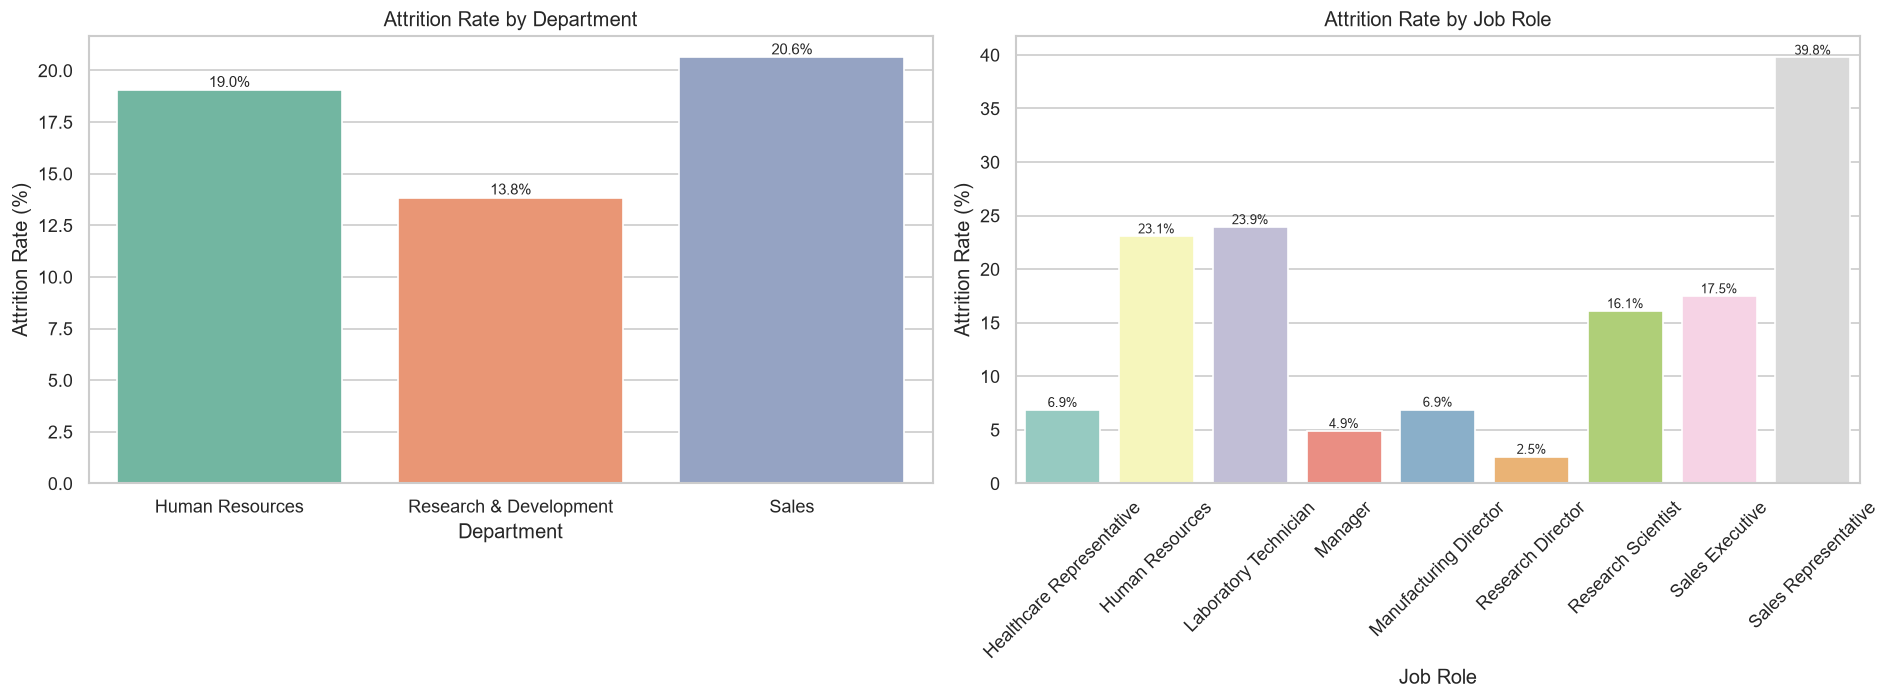

In [41]:
# ----------------------------------------------------------
# Chart 1: Attrition Rate by Department and Job Role
# ----------------------------------------------------------

# Calculate attrition rate by department
dept_rate = (
    raw.groupby("Department")["Attrition"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reset_index(name="Attrition Rate (%)")
)

# Calculate attrition rate by job role
job_rate = (
    raw.groupby("JobRole")["Attrition"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reset_index(name="Attrition Rate (%)")
)

fig, axes = plt.subplots(1, 2, figsize=(16,6))

# Department
sns.barplot(
    data=dept_rate,
    x="Department",
    y="Attrition Rate (%)",
    palette="Set2",
    ax=axes[0]
)

axes[0].set_title("Attrition Rate by Department")
axes[0].set_xlabel("Department")
axes[0].set_ylabel("Attrition Rate (%)")

# Job Role
sns.barplot(
    data=job_rate,
    x="JobRole",
    y="Attrition Rate (%)",
    palette="Set3",
    ax=axes[1]
)

axes[1].set_title("Attrition Rate by Job Role")
axes[1].set_xlabel("Job Role")
axes[1].set_ylabel("Attrition Rate (%)")
axes[1].tick_params(axis='x', rotation=45)

# ----------------------------------------------------------
# Add Percentage Labels
# ----------------------------------------------------------

for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.1f%%", fontsize=9)

for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.1f%%", fontsize=8)

plt.tight_layout()

plt.savefig("charts/chart1_attrition_rate.png")

plt.show()

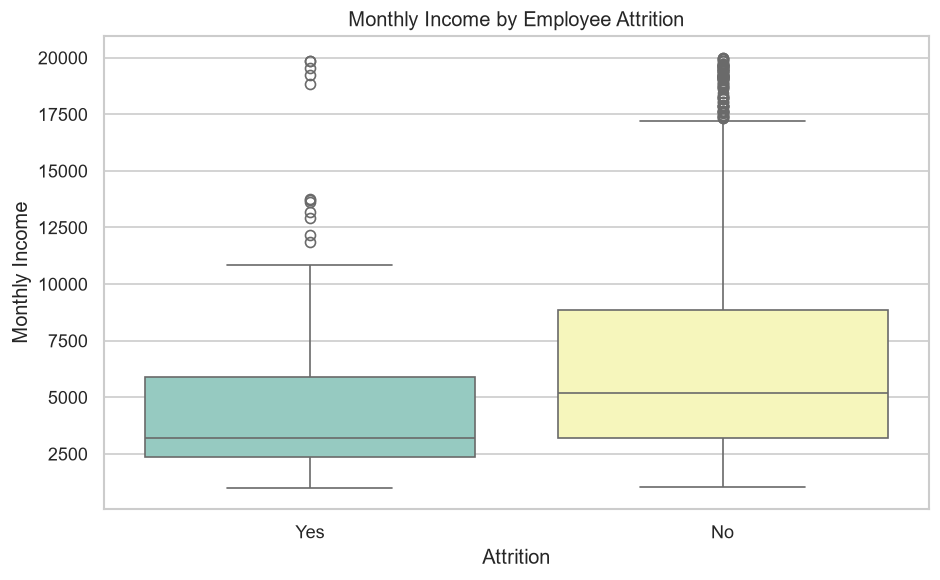

In [65]:
# ----------------------------------------------------------
# Chart 2: Monthly Income vs Attrition
# ----------------------------------------------------------

plt.figure(figsize=(8,5))

sns.boxplot(
    data=raw,
    x="Attrition",
    y="MonthlyIncome",
    palette="Set3"
)

plt.title("Monthly Income by Employee Attrition")
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")

plt.tight_layout()

plt.savefig("charts/chart2_income_boxplot.png")

plt.show()

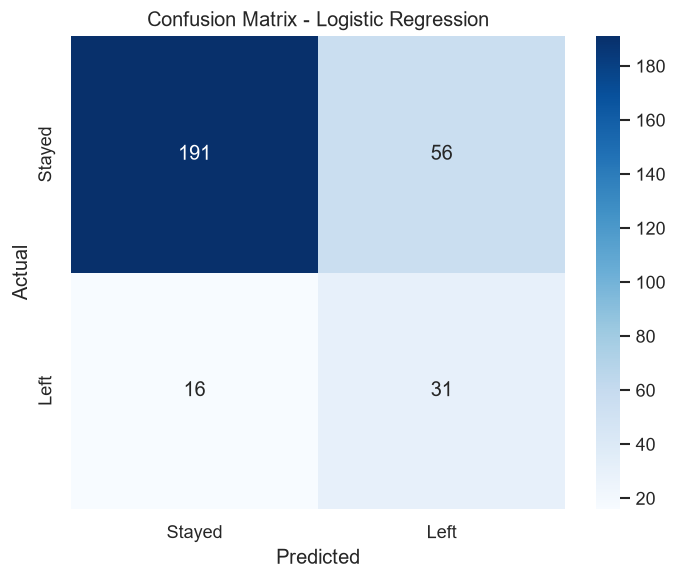

In [66]:
# ----------------------------------------------------------
# Chart 3: Confusion Matrix
# ----------------------------------------------------------

cm = confusion_matrix(y_test, log_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Stayed","Left"],
    yticklabels=["Stayed","Left"]
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()

plt.savefig("charts/chart3_confusion_matrix.png")

plt.show()

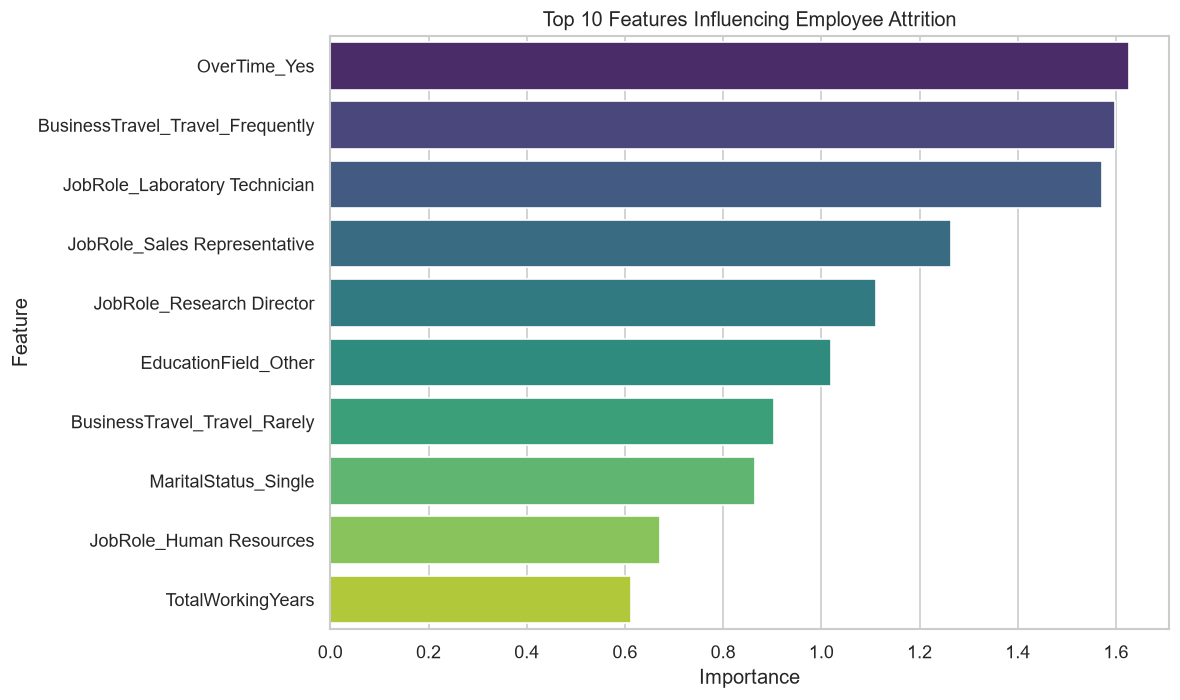

In [67]:
# ----------------------------------------------------------
# Chart 4: Top 10 Important Features
# ----------------------------------------------------------

top10 = importance.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top10,
    x="Importance",
    y="Feature",
    palette="viridis"
)

plt.title("Top 10 Features Influencing Employee Attrition")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()

plt.savefig("charts/chart4_feature_importance.png")

plt.show()

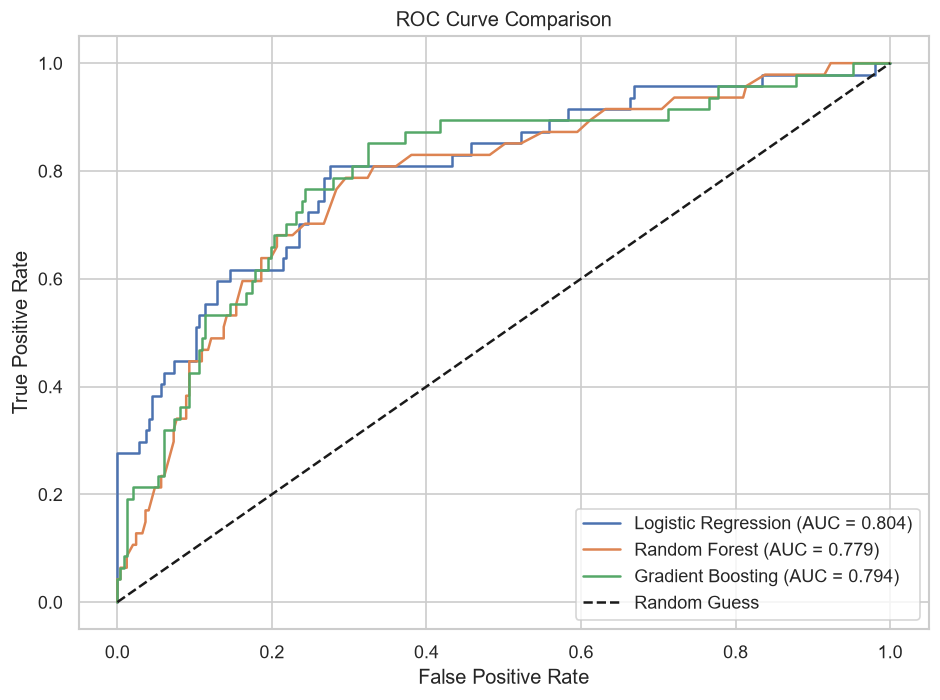

In [45]:
# ----------------------------------------------------------
# Chart 5: ROC Curve Comparison
# ----------------------------------------------------------

from sklearn.metrics import roc_curve

plt.figure(figsize=(8,6))

# Logistic Regression
fpr1, tpr1, _ = roc_curve(y_test, log_prob)
plt.plot(
    fpr1, tpr1,
    label=f"Logistic Regression (AUC = {roc_auc_score(y_test, log_prob):.3f})"
)

# Random Forest
fpr2, tpr2, _ = roc_curve(y_test, rf_prob)
plt.plot(
    fpr2, tpr2,
    label=f"Random Forest (AUC = {roc_auc_score(y_test, rf_prob):.3f})"
)

# Gradient Boosting
fpr3, tpr3, _ = roc_curve(y_test, gb_prob)
plt.plot(
    fpr3, tpr3,
    label=f"Gradient Boosting (AUC = {roc_auc_score(y_test, gb_prob):.3f})"
)

# Reference line
plt.plot([0, 1], [0, 1], "k--", label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

# Display all labels
plt.legend(loc="lower right")

plt.tight_layout()

plt.savefig("charts/chart5_roc_curve.png")

plt.show()

## Observation

The visualizations reveal several important patterns in employee attrition. Employees in the Sales department and certain job roles show higher attrition levels. Employees who left the company generally earned lower monthly incomes than those who stayed. The confusion matrix indicates that the Logistic Regression model correctly classified most employees, while the ROC curve confirms that it achieved the highest ROC-AUC score among the three models. Feature importance analysis highlights the employee characteristics that contribute most to predicting attrition.

# ==========================================================
# Task 7 - HR Insights & Business Recommendations
# ==========================================================

## HR Insights & Business Recommendations

### 1. Which three factors most strongly predict employee attrition?

The analysis shows that employee attrition is most strongly influenced by factors such as monthly income, overtime, and the number of years an employee has been with the company. Employees with lower salaries, those who frequently work overtime, and employees in the early years of their employment are more likely to leave.

### 2. Which department or job role should HR prioritize?

The Sales department experiences the highest number of employee exits, with Sales Representatives showing one of the highest attrition rates. HR should prioritize retention programs for these employees through regular engagement, career development opportunities, and improved work-life balance.

### 3. Does salary alone explain attrition?

No. Although lower income is associated with higher attrition, salary is not the only reason employees leave. Work-life balance, overtime, job role, career growth opportunities, and employee satisfaction also play significant roles in employee retention.

### 4. HR Recommendations

- Introduce targeted retention programs for employees during their first few years with the company, including mentoring, career planning, and regular feedback sessions.
- Reduce excessive overtime and improve work-life balance by monitoring employee workloads and encouraging flexible work practices where possible.

### 5. Model Limitation

This prediction model is based on historical employee data and identifies patterns rather than guaranteed outcomes. Human decisions are influenced by personal circumstances that may not be included in the dataset, so HR should use the predictions as a decision-support tool rather than as the sole basis for employee-related decisions.